In [1]:
import torch
import matplotlib.pyplot as plt
from util import load_model, load_config, value_factor, cove
from model import VFNN
from util import load_dataset, load_dataset_no_split, load_experiment
import pandas as pd
import numpy as np
from classical_strategies import base_load, base_load_modified
from tabulate import tabulate

In [50]:
model_1day_10, dataset, config = load_experiment('a73d6466-5da1-40a1-a3be-7e9377409fb0', '../data/processed/dataset_2018-21_clean.csv')
model_1day_5, _, _ = load_experiment('b4705a69-aa70-4861-9d78-bc5c7a609f8f', '../data/processed/dataset_2018-21_clean.csv')
model_1day_4, _, _ = load_experiment('9ffe020a-aabe-4cff-a07b-90e0a6f75702', '../data/processed/dataset_2018-21_clean.csv')
model_1day_3, _, _ = load_experiment('5860903f-10af-4971-9f9a-14e813385ff5', '../data/processed/dataset_2018-21_clean.csv')
model_1day_1, _, _ = load_experiment('9c82f6d8-280b-43f8-abbf-90b3d1a1a698', '../data/processed/dataset_2018-21_clean.csv')

/Users/zachl/Desktop/WindEnergyForecasting/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForecasting/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForecasting/src/util.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices[cap_idxs] = threshold
/Users/zachl/Desktop/WindEnergyForeca

In [54]:
idxs1mo = 24 * 30
idxs1yr = 24 * 365
dataset = dataset[:idxs1mo]
print(f'Length of dataset: {len(dataset)}')
power = dataset[:,0].detach().cpu().numpy().squeeze()
price = dataset[:,1].detach().cpu().numpy().squeeze()
x = np.arange(0, len(dataset))

Length of dataset: 720


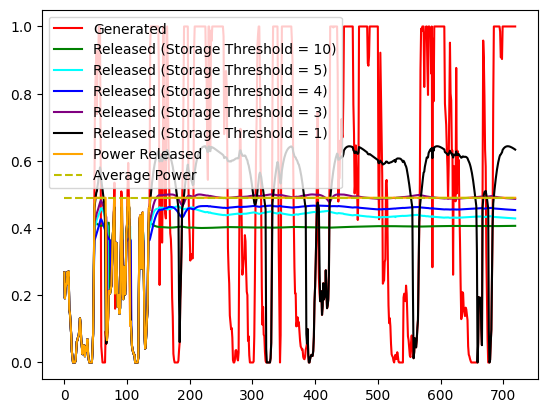

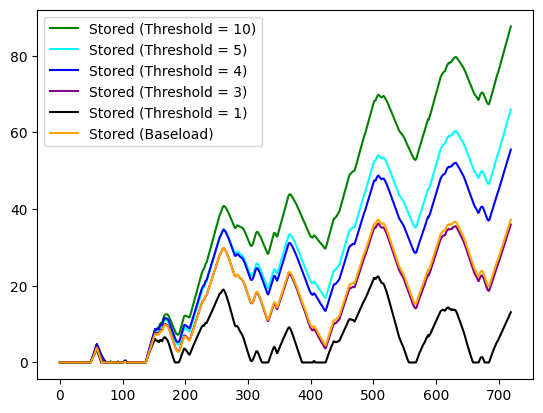

In [55]:
avg_power = np.repeat(np.mean(power), len(x))

pred_10 = model_1day_10(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
released_10 = pred_10[:,0]
stored_10 = pred_10[:,1]

pred_5 = model_1day_5(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
released_5 = pred_5[:,0]
stored_5 = pred_5[:,1]

pred_4 = model_1day_4(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
released_4 = pred_4[:,0]
stored_4 = pred_4[:,1]

pred_3 = model_1day_3(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
released_3 = pred_3[:,0]
stored_3 = pred_3[:,1]

pred_1 = model_1day_1(dataset.unsqueeze(0)).detach().cpu().numpy().squeeze()
released_1 = pred_1[:,0]
stored_1 = pred_1[:,1]

baseload_released, baseload_stored = base_load(power)

plt.plot(x, power, 'r', label='Generated')
plt.plot(x, released_10, 'g', label='Released (Storage Threshold = 10)')
plt.plot(x, released_5, 'cyan', label='Released (Storage Threshold = 5)')
plt.plot(x, released_4, 'b', label='Released (Storage Threshold = 4)')
plt.plot(x, released_3, 'purple', label='Released (Storage Threshold = 3)')
plt.plot(x, released_1, 'black', label='Released (Storage Threshold = 1)')
plt.plot(x, baseload_released, 'orange', label='Power Released')
plt.plot(x, avg_power, '--y', label='Average Power')
plt.legend()
plt.show()

plt.plot(x, stored_10, 'g', label='Stored (Threshold = 10)')
plt.plot(x, stored_5, 'cyan', label='Stored (Threshold = 5)')
plt.plot(x, stored_4, 'b', label='Stored (Threshold = 4)')
plt.plot(x, stored_3, 'purple', label='Stored (Threshold = 3)')
plt.plot(x, stored_1, 'black', label='Stored (Threshold = 1)')
plt.plot(x, baseload_stored, 'orange', label='Stored (Baseload)')
plt.legend()
plt.show()

In [56]:
vf_raw = value_factor(power, price)
cove_raw = cove(power, price)

vf_baseload = value_factor(baseload_released, price)
cove_baseload = cove(baseload_released, price)

vf_10 = value_factor(released_10, price)
cove_10 = cove(released_10, price)

vf_5 = value_factor(released_5, price)
cove_5 = cove(released_5, price)

vf_4 = value_factor(released_4, price)
cove_4 = cove(released_4, price)

vf_3 = value_factor(released_3, price)
cove_3 = cove(released_3, price)

vf_1 = value_factor(released_1, price)
cove_1 = cove(released_1, price)

metrics = np.array([["Raw", vf_raw, cove_raw, False],
                    ["Baseload", vf_baseload, cove_baseload, False],
                    ["VFNN (Storage Threshold = 10)", vf_10, cove_10, cove_10 < cove_baseload],
                    ["VFNN (Storage Threshold = 5)", vf_5, cove_5, cove_5 < cove_baseload],
                    ["VFNN (Storage Threshold = 4)", vf_4, cove_4, cove_4 < cove_baseload],
                    ["VFNN (Storage Threshold = 3)", vf_3, cove_3, cove_3 < cove_baseload],
                    ["VFNN (Storage Threshold = 1)", vf_1, cove_1, cove_1 < cove_baseload]])
headers = ["Strategy", "VF", "COVE", "Beats baseload?"]

# Generate the table in fancy format.
table = tabulate(metrics, headers, tablefmt="fancy_grid")

print(table)

╒═══════════════════════════════╤══════════╤══════════╤═══════════════════╕
│ Strategy                      │       VF │     COVE │ Beats baseload?   │
╞═══════════════════════════════╪══════════╪══════════╪═══════════════════╡
│ Raw                           │ 0.617963 │ 0.16055  │ False             │
├───────────────────────────────┼──────────┼──────────┼───────────────────┤
│ Baseload                      │ 0.968381 │ 0.114574 │ False             │
├───────────────────────────────┼──────────┼──────────┼───────────────────┤
│ VFNN (Storage Threshold = 10) │ 0.977268 │ 0.135175 │ False             │
├───────────────────────────────┼──────────┼──────────┼───────────────────┤
│ VFNN (Storage Threshold = 5)  │ 0.973164 │ 0.125458 │ False             │
├───────────────────────────────┼──────────┼──────────┼───────────────────┤
│ VFNN (Storage Threshold = 4)  │ 0.975451 │ 0.12076  │ False             │
├───────────────────────────────┼──────────┼──────────┼───────────────────┤
│ VFNN (Stor

0.49023217


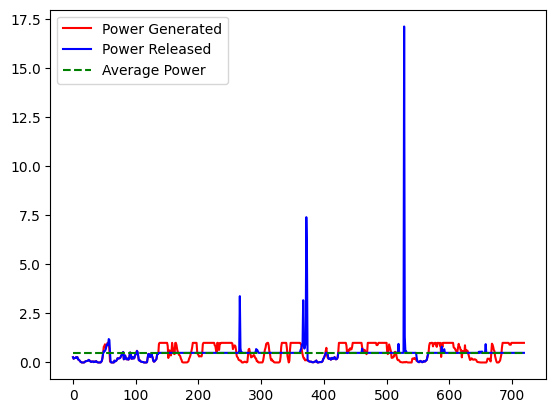

Raw VF: 0.6179627180099487
Modified Base Load VF: 3.348450548374885
Modified Base Load COVE: 0.03146337519416728


In [7]:
base_load_released = base_load_modified(power, price)

avg = np.repeat(np.mean(power), len(x))
plt.plot(x, power, 'r', label='Power Generated')
plt.plot(x, base_load_released, 'b', label='Power Released')
plt.plot(x, avg, '--g', label='Average Power')
plt.legend()
plt.show()

before_vf = value_factor(power, price)
after_vf = value_factor(base_load_released, price)
after_cove = cove(base_load_released, price)

print(f'Raw VF: {before_vf}')
print(f'Modified Base Load VF: {after_vf}')
print(f'Modified Base Load COVE: {after_cove}')